In [1]:
%load_ext sql
%env DATABASE_URL=mysql+mysqlconnector://root:root_pwd@db
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

env: DATABASE_URL=mysql+mysqlconnector://root:root_pwd@db


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 06 More on queries 

Let's import a well-structured database, with several tables and relationships, to be used as a sandbox for further exercises on queries.

The database is freely available and is taken from the IMDb (Internet Movie Database) website (https://www.imdb.com/interfaces/), although severely slimmed down.

This database contains several tables with information about movies, TV shows, people involved in the entertainment industry, and more, spanning from the 1890s to recent years.

To simplify the execution of queries, we will work with a slimmed-down version of the entire database, with still plenty of records for us to extract interesting information.

To start working with the IMDb database, we need to import it into our environment. The database `.sql` file should be downloaded from the link on Moodle and copied into the `/mysql/dbs` folder of the GitHub repository so that it will be found in the mounted volume at the location: `/mapd-workspace/dbs/IMDb_pruned.sql`.

1. Create a new DB named `IMDb`
2. Import the content of the file `/mapd-workspace/dbs/IMDb_pruned.sql` into the newly created DB
(this might take a minute or two...)

In [3]:
%%sql
SHOW DATABASES;

4 rows affected.


Database
information_schema
mysql
performance_schema
sys


In [4]:
%%sql
CREATE DATABASE IF NOT EXISTS IMDb;
SHOW DATABASES;

 * mysql+mysqlconnector://root:***@db
1 rows affected.
5 rows affected.


Database
IMDb
information_schema
mysql
performance_schema
sys


### Check which tables are available

In [5]:
%%sql
USE IMDb;
SHOW TABLES;

 * mysql+mysqlconnector://root:***@db
0 rows affected.
7 rows affected.


Tables_in_IMDb
Directors
Episode_belongs_to
Had_role
Names_
Title_genres
Title_ratings
Titles


### Describe the content of table `Names_`

In [14]:
%%sql
DESCRIBE Names_;

 * mysql+mysqlconnector://root:***@db
4 rows affected.


Field,Type,Null,Key,Default,Extra
name_id,varchar(255),NO,,None,
name_,varchar(255),NO,,None,
birth_year,smallint,YES,,None,
death_year,smallint,YES,,None,


### Study the distribution of the year of birth of all people included in the database

1. Start by limiting the query to 1000 entries
    1. Draw a histogram of the year of birth
    1. Draw a second histogram with the year of birth of the 1000 youngest people in the list

 * mysql+mysqlconnector://root:***@db
1000 rows affected.


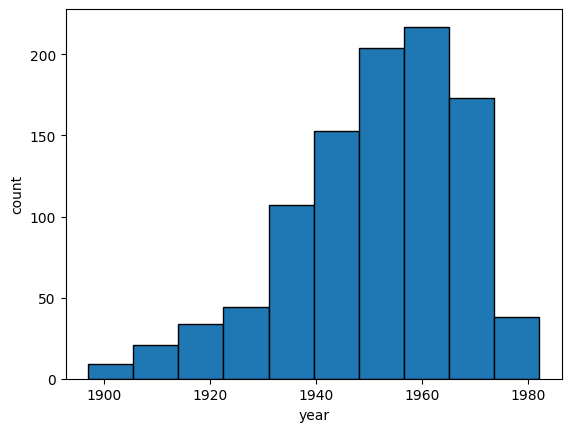

In [15]:
# 1.A
res = %sql SELECT * FROM Names_ LIMIT 1000;

birth_years = res.dict()["birth_year"]

plt.hist(birth_years, edgecolor="k")
plt.xlabel("year")
plt.ylabel("count");

 * mysql+mysqlconnector://root:***@db
1000 rows affected.


Text(0, 0.5, 'count')

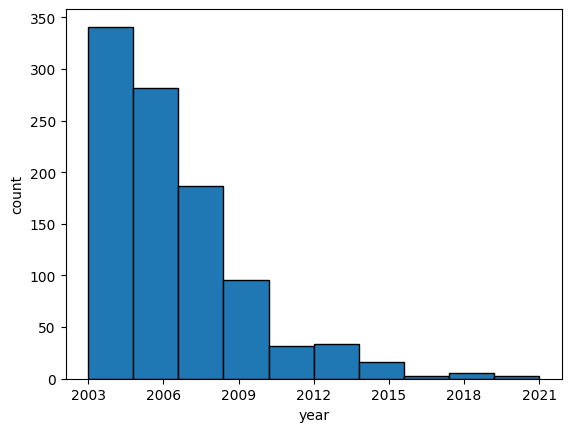

In [16]:
# 1.B
res = %sql SELECT * FROM Names_ ORDER BY birth_year DESC LIMIT 1000;
birth_year = res.dict()["birth_year"]
plt.hist(birth_year, edgecolor="k")
plt.xticks(np.linspace(min(birth_year), max(birth_year), 7, dtype=int))
plt.xlabel("year")
plt.ylabel("count")

2. Extend the query to all records in the table
    1. Check for outliers (inspect min and max)
    2. If any outlier is found, limit the query to a reasonable range (say... at least people born after 1850)
    3. Draw a new histogram with the year of birth
    4. Compute the mean and standard deviation of the year of birth

In [18]:
# 2.A
res = %sql SELECT MIN(birth_year) AS Oldest, MAX(birth_year) AS Youngest FROM Names_;
res

 * mysql+mysqlconnector://root:***@db
1 rows affected.


Oldest,Youngest
13,2021


In [25]:
# 2.B
res = %sql SELECT * FROM Names_ WHERE birth_year > 1850;
birth_years = res.dict()["birth_year"]

 * mysql+mysqlconnector://root:***@db
156309 rows affected.


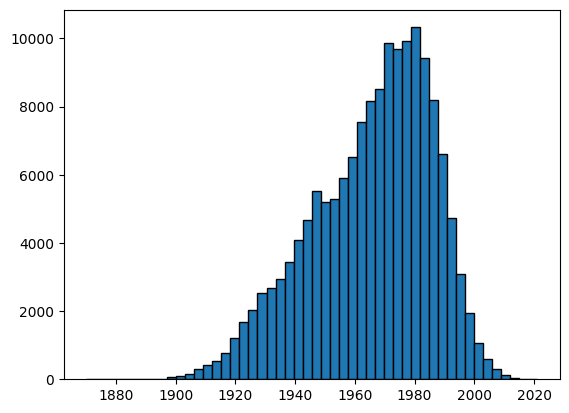

In [30]:
# 2.C
plt.hist(birth_years, bins=50, edgecolor="k");

In [44]:
# 2.D
res = %sql SELECT AVG(birth_year) Mean, STD(birth_year) STD FROM Names_;
res

 * mysql+mysqlconnector://root:***@db
1 rows affected.


Mean,STD
1965.4332,20.712074263741645


### Movie stats

1. Plot the number of titles available in the database for each year over the past 25 years.
2. List the names of all actors who have portrayed the character Spider-Man in movies, along with the corresponding movie titles.
3. List and count the top 10 people who have appeared the most in movies directed by Wes Anderson.

#### 1 - Plot the number of titles available in the database for each year over the past 25 years.

In [46]:
%%sql
SHOW TABLES;

 * mysql+mysqlconnector://root:***@db
7 rows affected.


Tables_in_IMDb
Directors
Episode_belongs_to
Had_role
Names_
Title_genres
Title_ratings
Titles


 * mysql+mysqlconnector://root:***@db
28 rows affected.


Text(0, 0.5, 'counts')

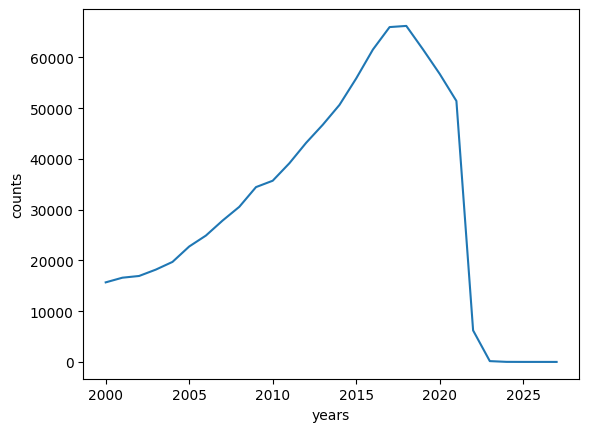

In [78]:
res = %sql SELECT start_year year, COUNT(*) count FROM Titles \
WHERE start_year >= 2000 GROUP BY start_year ORDER BY start_year DESC;
plt.plot("year", "count", data=res.dict())
plt.xlabel("years")
plt.ylabel("counts")

#### 2 - List the names of all actors who have portrayed the character Spider-Man in movies, along with the corresponding movie titles.

In [20]:
%%sql
SELECT name_, t.primary_title, t.start_year FROM Names_ n, Had_role r, Titles t
WHERE (n.name_id = r.name_id) AND (r.role_ LIKE "Spider-Man") 
AND (t.title_id = r.title_id) AND (t.title_type = "movie")
ORDER BY t.start_year;

 * mysql+mysqlconnector://root:***@db
8 rows affected.


name_,primary_title,start_year
Tobey Maguire,Spider-Man,2002
Tobey Maguire,Spider-Man 2,2004
Tobey Maguire,Spider-Man 3,2007
Andrew Garfield,The Amazing Spider-Man,2012
Andrew Garfield,The Amazing Spider-Man 2,2014
Tom Holland,Spider-Man: Homecoming,2017
Tom Holland,Spider-Man: Far from Home,2019
Tom Holland,Spider-Man: No Way Home,2021


alternatively

In [27]:
%%sql
SELECT n.name_, t.primary_title, t.start_year
FROM Names_ n
INNER JOIN Had_role r ON n.name_id = r.name_id
INNER JOIN Titles t ON t.title_id = r.title_id
WHERE (t.title_type = "movie")
AND (r.role_ = "Spider-Man")
ORDER BY t.start_year;

 * mysql+mysqlconnector://root:***@db
8 rows affected.


name_,primary_title,start_year
Tobey Maguire,Spider-Man,2002
Tobey Maguire,Spider-Man 2,2004
Tobey Maguire,Spider-Man 3,2007
Andrew Garfield,The Amazing Spider-Man,2012
Andrew Garfield,The Amazing Spider-Man 2,2014
Tom Holland,Spider-Man: Homecoming,2017
Tom Holland,Spider-Man: Far from Home,2019
Tom Holland,Spider-Man: No Way Home,2021


#### 3 - List and count the top 10 people who have appeared the most in movies directed by Wes Anderson.

In [45]:
%%sql
USE IMDb;

 * mysql+mysqlconnector://root:***@db
0 rows affected.


[]

In [60]:
%%sql
# TODO

 * mysql+mysqlconnector://root:***@db
0 rows affected.


[]

### Is IMDB only about movies?
1. Check the number of different media types contained in the database
1. Plot a histogram summarizing the number of titles per media type
1. Find the name and rating of the oldest videogame stored in the database

#### 1 - Check the number of different media types contained in the database

In [65]:
%%sql

SELECT DISTINCT title_type 
FROM Titles;

 * mysql+mysqlconnector://root:***@db
5 rows affected.


title_type
movie
tvEpisode
tvSeries
tvMiniSeries
videoGame


#### 2 - Plot a histogram summarizing the number of titles per media type

 * mysql+mysqlconnector://root:***@db
5 rows affected.


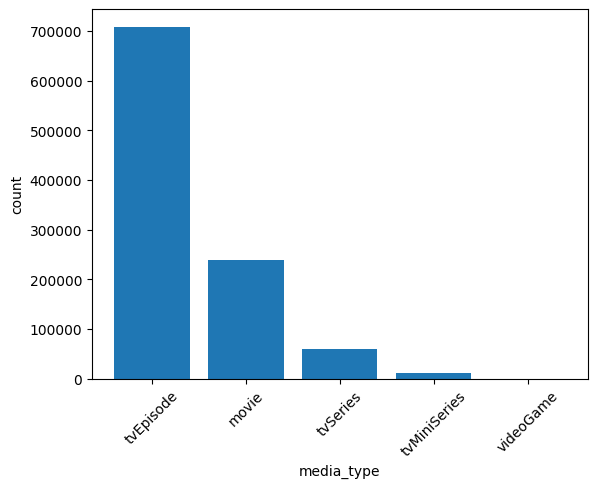

In [88]:
res = %sql SELECT title_type media_type, COUNT(*) count FROM Titles GROUP BY title_type ORDER BY count DESC;
res.bar();

#### 3 - Find the name and rating of the oldest videogame stored in the database 

In [95]:
%%sql
SELECT title_type, primary_title, start_year, average_rating
FROM Titles t
INNER JOIN Title_ratings r ON t.title_id = r.title_id
WHERE (start_year > 1900)
AND (title_type LIKE "videoGame")
ORDER BY start_year
LIMIT 10;

 * mysql+mysqlconnector://root:***@db
10 rows affected.


title_type,primary_title,start_year,average_rating
videoGame,Lord of the Rings,1990,6.9
videoGame,The Simpsons,1991,8.4
videoGame,Land of Illusion,1993,7.3
videoGame,Sim City Enhanced CD-ROM,1993,7.0
videoGame,Alien Carnage,1993,6.8
videoGame,Star Trek the Next Generation Interactive VHS Board Game,1993,8.2
videoGame,Crusader of Centy,1994,8.0
videoGame,Ride for Your Life,1995,5.9
videoGame,Mr. Payback: An Interactive Movie,1995,4.7
videoGame,Maximum Surge,1996,4.1


### Identify interesting outliers 

1. List the names of all movies whose titles begin with "The" and have a runtime between 3 and 4 hours.
2. What actor had the most roles as 'Self'?
3. Identify what TV series had more than 1,000 episodes, and identify in what year it was aired the first- and last-episode

#### 1 - List the names of all movies whose titles begin with "The" and have a runtime between 3 and 4 hours.

In [97]:
%%sql
SELECT * 
FROM Titles t
WHERE t.title_type LIKE "movie"
LIMIT 10;

 * mysql+mysqlconnector://root:***@db
10 rows affected.


title_id,title_type,primary_title,start_year,runtime_minutes
tt0011216,movie,Spanish Fiesta,2019,67
tt0015724,movie,Dama de noche,1993,102
tt0035423,movie,Kate & Leopold,2001,118
tt0059325,movie,Born in '45,1990,100
tt0059900,movie,"Wenn du groß bist, lieber Adam",1990,78
tt0062336,movie,The Tango of the Widower and Its Distorting Mirror,2020,70
tt0063351,movie,Summer in Narita,2012,108
tt0065188,movie,"Vojtech, receny sirotek",1990,80
tt0067460,movie,My Kingdom for...,1995,85
tt0068494,movie,Domo Arigato,1990,91


#### 2 - What actor had the most roles as 'Self'?

#### 3 - Identify what TV series had more than 1,000 episodes, and identify in what year it was aired the first episode

### It's all about the ratings 

1. Group all movies by decade and plot their overall rating distribution trend. Limit the query to the movies with at least 1000 ratings.
2. Plot the average rating of each episode of "Games of Thrones". Group by season and compute the average and standard deviation for each season
3. Plot the total number of movies produced per year, divided by genre (Action, Comedy, Drama, Thriller, Fantasy), and the yearly rating average per genre

#### 1 - Group all movies by decade and plot their overall rating distribution trend. Limit the query to the movies with at least 1000 ratings.

#### 2 - Plot the average rating of each episode of "Games of Thrones". Group by season and compute the average and standard deviation for each season.

#### 3 - Plot the total number of movies produced per year, divided by genre (Action, Comedy, Drama, Thriller, Fantasy), and the yearly rating average per genre